# Benchmarks

**Purpose.** Quantify pipeline-regression measurements and compare the runtime, memory use, and storage footprint of the legacy, curated, and IMG-enhanced databases.

**Data.** Versioned TSV tables under `docs/data/`, derived from fresh-work GNU-time trials and archive-validated database builds.

**Analysis plan.**

1. Validate the raw trial and storage schemas.
2. Exclude the declared warm-up from descriptive medians.
3. Plot every measured replicate with its median.
4. Compare the three database profiles under the same end-to-end workload.
5. Plot installed database bytes by runtime component.

**Outputs.** Three publication-style figures in SVG and 600-dpi PNG, compact summary tables, and assertions that fail the documentation build when data contracts drift.

## Environment

The notebook runs with the named `ssuextract-docs` kernel from the dedicated documentation lock. From the repository root, execute `pixi run --manifest-path docs-env/pixi.toml register-kernel`, followed by `pixi run --manifest-path docs-env/pixi.toml execute-notebooks`.

The setup cell locates the repository from `mkdocs.yml`, applies the shared publication style, and creates the figure directory.

- Expected: resolved project and data directories.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'mkdocs.yml').is_file() and (candidate / 'docs/data').is_dir():
            return candidate
    raise FileNotFoundError('could not locate mkdocs.yml and docs/data')

ROOT = find_project_root(Path.cwd().resolve())
DOCS = ROOT / 'docs'
FIGURES = DOCS / 'assets' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / 'notebooks'))
from beautiful_style import finalize_axes, set_beautiful_style

set_beautiful_style(medium='paper', background='light', dpi=180)
plt.ioff()
try:
    from matplotlib_inline.backend_inline import flush_figures
    get_ipython().events.unregister('post_execute', flush_figures)
except (ImportError, ValueError):
    pass

print(f'project_root={ROOT}')
print(f'data_directory={DOCS / "data"}')

project_root=/clusterfs/jgi/scratch/science/mgs/nelli/frederik/projects/apps/ssuextract
data_directory=/clusterfs/jgi/scratch/science/mgs/nelli/frederik/projects/apps/ssuextract/docs/data


## Pipeline regression data

Load one warm-up and three measured trials for each implementation. Validate positive timing and memory values before calculating medians.

- Expected: two implementations with three measured replicates each.

In [2]:
pipeline = pd.read_csv(DOCS / 'data' / 'pipeline_benchmark.tsv', sep='\t')
required = {'implementation', 'trial', 'warmup', 'elapsed_seconds', 'peak_rss_kb'}
assert required <= set(pipeline.columns)
assert pipeline['elapsed_seconds'].gt(0).all()
assert pipeline['peak_rss_kb'].gt(0).all()
assert pipeline.groupby('implementation')['warmup'].sum().eq(1).all()

measured = pipeline.loc[~pipeline['warmup']].copy()
assert measured.groupby('implementation').size().eq(3).all()
measured['peak_rss_gib'] = measured['peak_rss_kb'] / 1024**2
runtime_summary = (
    measured.groupby('implementation', sort=False)
    .agg(measured_trials=('trial', 'size'), median_seconds=('elapsed_seconds', 'median'), median_peak_rss_gib=('peak_rss_gib', 'median'))
    .reset_index()
)
display(runtime_summary.round({'median_seconds': 2, 'median_peak_rss_gib': 3}))

,implementation,measured_trials,median_seconds,median_peak_rss_gib
0,620b1a6 baseline,3,96.34,2.678
1,1.1.0 candidate,3,95.63,2.678


Plot all measured replicates as points and the median as a vertical mark. A dot plot permits a restricted numeric range without implying that bar length begins at zero.

- Expected: overlapping runtime and memory distributions with labeled medians.

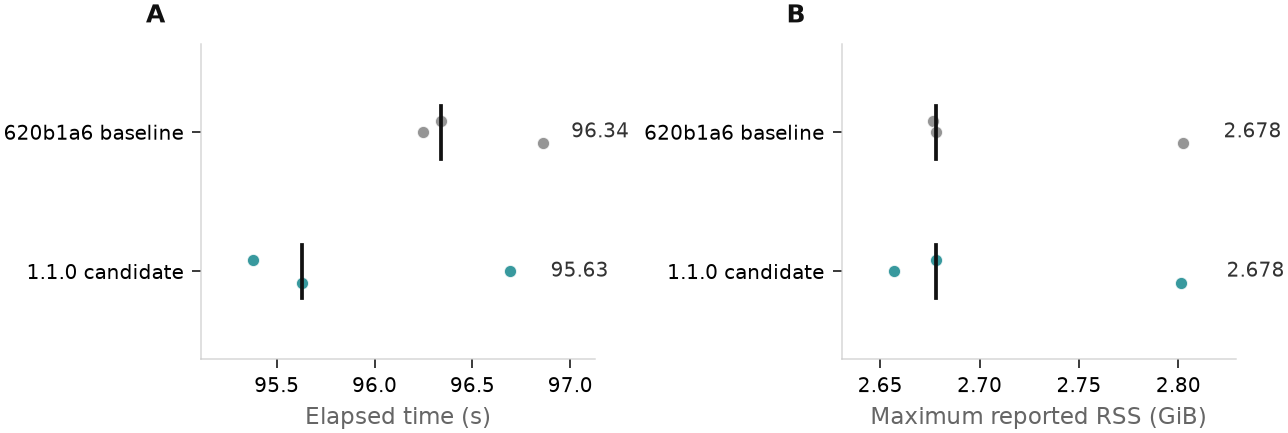

In [3]:
labels = list(measured['implementation'].drop_duplicates())
colors = {'620b1a6 baseline': '#777777', '1.1.0 candidate': '#007C83'}
assert set(labels) == set(colors)
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.45), constrained_layout=True)
panels = [('elapsed_seconds', 'Elapsed time (s)', '{:.2f}'), ('peak_rss_gib', 'Maximum reported RSS (GiB)', '{:.3f}')]
for panel_label, ax, (column, xlabel, number_format) in zip(('A', 'B'), axes, panels):
    for y, label in enumerate(labels):
        values = measured.loc[measured['implementation'].eq(label), column].to_numpy()
        offsets = np.linspace(-0.08, 0.08, len(values))
        ax.scatter(values, y + offsets, s=24, color=colors[label], alpha=0.78, edgecolor='white', linewidth=0.45, zorder=3)
        median = float(np.median(values))
        ax.plot([median, median], [y - 0.19, y + 0.19], color='#111111', linewidth=1.5, zorder=4)
        span = max(values) - min(values)
        ax.text(max(values) + max(span * 0.16, median * 0.0015), y, number_format.format(median), va='center', fontsize=8, color='#333333')
    ax.set_yticks(range(len(labels)), labels)
    ax.invert_yaxis()
    ax.margins(x=0.18, y=0.32)
    finalize_axes(ax, xlabel=xlabel)
    ax.text(-0.14, 1.05, panel_label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom')
fig.savefig(FIGURES / 'pipeline-regression.svg')
fig.savefig(FIGURES / 'pipeline-regression.png', dpi=600)
fig

In [4]:
baseline = runtime_summary.set_index('implementation').loc['620b1a6 baseline']
candidate = runtime_summary.set_index('implementation').loc['1.1.0 candidate']
display(Markdown(
    '**Figure 1. Runtime and memory remained effectively unchanged after the SSUextract 1.1 pipeline redesign.** '
    'Points show three fresh-work measured trials on the bundled example; vertical marks and adjacent values show medians. '
    f'Median elapsed time was {baseline.median_seconds:.2f} s for commit `620b1a6` and '
    f'{candidate.median_seconds:.2f} s for the 1.1.0 candidate. Median GNU-time maximum reported RSS was '
    f'{baseline.median_peak_rss_gib:.3f} GiB and {candidate.median_peak_rss_gib:.3f} GiB, respectively. '
    'Trial 0 was a warm-up and is excluded.'
))

**Figure 1. Runtime and memory remained effectively unchanged after the SSUextract 1.1 pipeline redesign.** Points show three fresh-work measured trials on the bundled example; vertical marks and adjacent values show medians. Median elapsed time was 96.34 s for commit `620b1a6` and 95.63 s for the 1.1.0 candidate. Median GNU-time maximum reported RSS was 2.678 GiB and 2.678 GiB, respectively. Trial 0 was a warm-up and is excluded.

## Database-profile performance

Load one warm-up and three measured full-pipeline trials for each database profile. Every trial uses the same assembly, covariance models, thread limits, and fresh Nextflow work directory.

- Expected: legacy, curated, and IMG-enhanced profiles with three measured replicates each.

In [5]:
database_runtime = pd.read_csv(DOCS / 'data' / 'database_profile_benchmark.tsv', sep='\t')
required = {'profile', 'trial', 'warmup', 'elapsed_seconds', 'peak_rss_kb'}
assert required <= set(database_runtime.columns)
expected_profiles = list(database_runtime['profile'].drop_duplicates())
assert len(expected_profiles) == 3
assert database_runtime['elapsed_seconds'].gt(0).all()
assert database_runtime['peak_rss_kb'].gt(0).all()
assert database_runtime.groupby('profile')['warmup'].sum().eq(1).all()

database_measured = database_runtime.loc[~database_runtime['warmup']].copy()
assert database_measured.groupby('profile').size().eq(3).all()
database_measured['peak_rss_gib'] = database_measured['peak_rss_kb'] / 1024**2
database_runtime_summary = (
    database_measured.groupby('profile', sort=False)
    .agg(measured_trials=('trial', 'size'), median_seconds=('elapsed_seconds', 'median'), median_peak_rss_gib=('peak_rss_gib', 'median'))
    .reset_index()
)
display(database_runtime_summary.round({'median_seconds': 2, 'median_peak_rss_gib': 3}))

,profile,measured_trials,median_seconds,median_peak_rss_gib
0,Legacy 138.1/4.12,3,80.22,2.798
1,Curated 138.2/5.1.1,3,55.01,2.786
2,IMG-enhanced 138.2/5.1.1,3,72.60,2.789


Plot every measured replicate and mark the median. Shared axes expose the runtime and memory cost of adding the updated references and IMG sequences.

- Expected: three directly comparable distributions without inferential error bars.

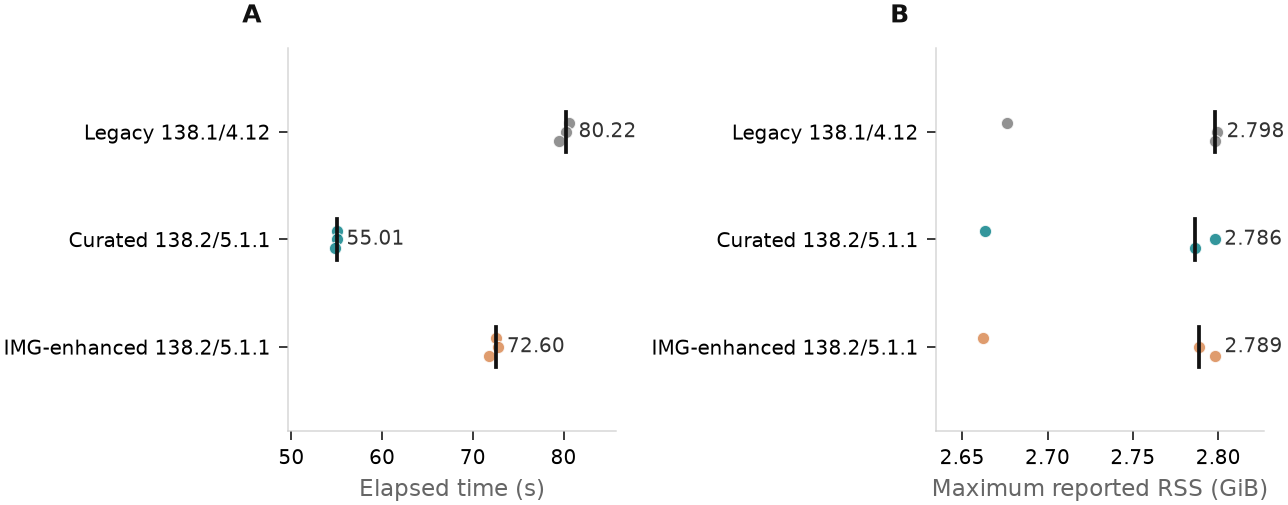

In [6]:
database_colors = {
    'Legacy 138.1/4.12': '#777777',
    'Curated 138.2/5.1.1': '#007C83',
    'IMG-enhanced 138.2/5.1.1': '#D7834A',
}
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.85), constrained_layout=True)
panels = [('elapsed_seconds', 'Elapsed time (s)', '{:.2f}'), ('peak_rss_gib', 'Maximum reported RSS (GiB)', '{:.3f}')]
for panel_label, ax, (column, xlabel, number_format) in zip(('A', 'B'), axes, panels):
    panel_values = database_measured[column].to_numpy()
    label_offset = max(np.ptp(panel_values) * 0.04, np.median(panel_values) * 0.002)
    for y, label in enumerate(expected_profiles):
        values = database_measured.loc[database_measured['profile'].eq(label), column].to_numpy()
        offsets = np.linspace(-0.08, 0.08, len(values))
        ax.scatter(values, y + offsets, s=24, color=database_colors[label], alpha=0.8, edgecolor='white', linewidth=0.45, zorder=3)
        median = float(np.median(values))
        ax.plot([median, median], [y - 0.19, y + 0.19], color='#111111', linewidth=1.5, zorder=4)
        ax.text(max(values) + label_offset, y, number_format.format(median), va='center', fontsize=8, color='#333333')
    ax.set_yticks(range(len(expected_profiles)), expected_profiles)
    ax.invert_yaxis()
    ax.margins(x=0.2, y=0.25)
    finalize_axes(ax, xlabel=xlabel)
    ax.text(-0.14, 1.05, panel_label, transform=ax.transAxes, fontsize=10, fontweight='bold', va='bottom')
fig.savefig(FIGURES / 'database-profile-performance.svg')
fig.savefig(FIGURES / 'database-profile-performance.png', dpi=600)
fig

**Figure 2. End-to-end performance of the three database profiles.** Points show three measured fresh-work trials on the bundled assembly; vertical marks and adjacent values show medians. Every trial used two threads per search task and an eight-CPU Nextflow task ceiling. RSS is GNU time's maximum reported value for the wrapped Nextflow command, not aggregate concurrent memory. Trial 0 was a warm-up and is excluded.

## Database footprint

Load apparent bytes for runtime database components and verify that they sum to the installed total. The compressed archive is reported separately from installed files.

- Expected: legacy, curated, and IMG-enhanced installations with exact component totals and validated archive hashes.

In [7]:
storage = pd.read_csv(DOCS / 'data' / 'database_storage.tsv', sep='\t')
components = ['source_fasta_bytes', 'blast_bytes', 'parquet_bytes', 'other_bytes']
assert {'profile', 'installed_bytes', 'archive_bytes', 'archive_sha256', *components} <= set(storage.columns)
assert list(storage['profile']) == expected_profiles
assert storage[components].sum(axis=1).eq(storage['installed_bytes']).all()
release_storage = storage.loc[~storage['profile'].str.startswith('Legacy')]
assert release_storage['archive_bytes'].gt(0).all()
assert release_storage['archive_sha256'].str.fullmatch(r'[0-9a-f]{64}').all()
storage_view = storage[['profile', 'installed_bytes', 'archive_bytes']].copy()
storage_view['installed_GiB'] = storage_view.pop('installed_bytes') / 1024**3
storage_view['archive_GiB'] = storage_view.pop('archive_bytes') / 1024**3
display(storage_view.round(3))
for profile in expected_profiles[1:]:
    ratio = storage.loc[storage['profile'].eq(profile), 'installed_bytes'].iloc[0] / storage.loc[storage['profile'].eq(expected_profiles[0]), 'installed_bytes'].iloc[0]
    print(f'{profile} installed size vs legacy={ratio:.1%}')

,profile,installed_GiB,archive_GiB
0,Legacy 138.1/4.12,1.429,NaN
1,Curated 138.2/5.1.1,0.570,0.337
2,IMG-enhanced 138.2/5.1.1,1.316,0.810


Curated 138.2/5.1.1 installed size vs legacy=39.9%
IMG-enhanced 138.2/5.1.1 installed size vs legacy=92.1%


Plot installed bytes as horizontal stacked bars. Position and segment labels carry the values; color separates storage roles rather than database identity.

- Expected: all three installed profiles on one common byte scale.

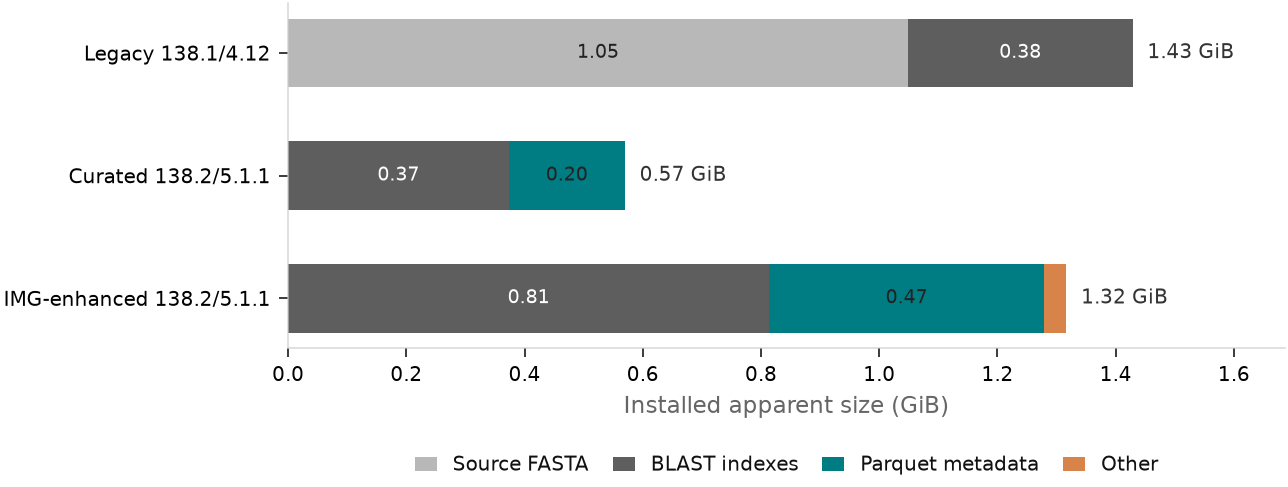

In [8]:
component_labels = {'source_fasta_bytes': 'Source FASTA', 'blast_bytes': 'BLAST indexes', 'parquet_bytes': 'Parquet metadata', 'other_bytes': 'Other'}
component_colors = {'source_fasta_bytes': '#B8B8B8', 'blast_bytes': '#5E5E5E', 'parquet_bytes': '#007C83', 'other_bytes': '#D7834A'}
fig, ax = plt.subplots(figsize=(7.2, 2.75), constrained_layout=True)
left = np.zeros(len(storage))
for component in components:
    widths = storage[component].to_numpy() / 1024**3
    bars = ax.barh(storage['profile'], widths, left=left, height=0.56, color=component_colors[component], label=component_labels[component])
    for bar, width in zip(bars, widths):
        if width >= 0.12:
            ax.text(bar.get_x() + width / 2, bar.get_y() + bar.get_height() / 2, f'{width:.2f}', ha='center', va='center', fontsize=7.5, color='white' if component == 'blast_bytes' else '#222222')
    left += widths
for y, total in enumerate(storage['installed_bytes'] / 1024**3):
    ax.text(total + 0.025, y, f'{total:.2f} GiB', va='center', fontsize=8, color='#333333')
ax.invert_yaxis()
ax.set_xlim(0, left.max() * 1.18)
finalize_axes(ax, xlabel='Installed apparent size (GiB)')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.42), ncol=4, handlelength=1.1, columnspacing=1.2)
fig.savefig(FIGURES / 'database-footprint.svg')
fig.savefig(FIGURES / 'database-footprint.png', dpi=600)
fig

**Figure 3. Installed database footprint by runtime component.** Logical file bytes are split among source FASTA, BLAST indexes, Parquet metadata, and other manifest or provenance files. Compressed release archives are reported in the table above and excluded from the bars. Values inside segments are GiB.

In [9]:
runtime_delta = abs(float(baseline.median_seconds - candidate.median_seconds))
runtime_delta_percent = runtime_delta / float(baseline.median_seconds)
display(Markdown(
    '## Interpretation\n\n'
    f'The pipeline redesign is runtime-neutral on the bundled workload: the measured median differs by '
    f'{runtime_delta:.2f} s ({runtime_delta_percent:.1%}), while maximum reported RSS differs by '
    f'{abs(float(baseline.median_peak_rss_gib - candidate.median_peak_rss_gib)):.3f} GiB at the reported precision. '
    'The database-profile panels separate the cost of current references from the additional IMG sequence content. '
    'Parquet stores taxonomy and provenance lookups; sequence search retains native BLAST indexes.\n\n'
    'These measurements cover one bundled workload and three measured replicates per implementation. They do not '
    'estimate general sensitivity, recall, taxonomic accuracy, or performance on larger assemblies.\n\n'
    '## Figure revision log\n\n'
    '- Initial design uses raw replicate dots, median marks, direct values, paper typography, and no inferential error bars.\n'
    '- First inspection confirmed readable axes, labels, and grayscale separation; the shared style helper was moved outside '
    'the published documentation tree and the single-panel storage label was removed.\n'
    '- The three-profile design adds raw replicate points and direct medians for runtime and memory, plus one shared storage '
    'scale. Final visual inspection follows the dependency-complete database benchmark.'
))

## Interpretation

The pipeline redesign is runtime-neutral on the bundled workload: the measured median differs by 0.71 s (0.7%), while maximum reported RSS differs by 0.000 GiB at the reported precision. The database-profile panels separate the cost of current references from the additional IMG sequence content. Parquet stores taxonomy and provenance lookups; sequence search retains native BLAST indexes.

These measurements cover one bundled workload and three measured replicates per implementation. They do not estimate general sensitivity, recall, taxonomic accuracy, or performance on larger assemblies.

## Figure revision log

- Initial design uses raw replicate dots, median marks, direct values, paper typography, and no inferential error bars.
- First inspection confirmed readable axes, labels, and grayscale separation; the shared style helper was moved outside the published documentation tree and the single-panel storage label was removed.
- The three-profile design adds raw replicate points and direct medians for runtime and memory, plus one shared storage scale. Final visual inspection follows the dependency-complete database benchmark.